# Exploratory Data Analysis

## Purpose
Understand patterns, distributions, and relationships
in the HR dataset through 15 visualizations.
Every chart includes an executive-style business interpretation.

## Input
data/processed/employee_features.csv

## Output
15 chart images saved to images/ folder 

In [1]:
# ── Imports, Settings, Load Data ──

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── File paths ──
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

input_path  = os.path.join(project_root, 'data', 'processed',
                            'employee_features.csv')
images_dir  = os.path.join(project_root, 'images')
os.makedirs(images_dir, exist_ok=True)

# ── Load data ──
df = pd.read_csv(input_path)

# ── Professional chart style ──
plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.dpi'        : 120,
})

# ── Color palette ──
# Professional HR analytics color scheme
C_BLUE    = '#2E4057'   # Dark blue   → primary bars
C_TEAL    = '#048A81'   # Teal        → secondary
C_ORANGE  = '#EF8354'   # Orange      → warning / medium
C_RED     = '#E84855'   # Red         → alert / high risk
C_GREEN   = '#3BB273'   # Green       → positive / good
C_LIGHT   = '#54C6EB'   # Light blue  → accent
C_YELLOW  = '#F0C987'   # Yellow      → neutral middle

PALETTE_5 = [C_GREEN, C_TEAL, C_YELLOW, C_ORANGE, C_RED]

print(f"Setup complete")
print(f"Data loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Images saved : {images_dir}")
print(f"Chart style  : Professional HR Analytics") 

Setup complete
Data loaded  : 2,600 rows × 53 columns
Images saved : C:\Users\ganti_kvd0xe3\OneDrive\Sathya\employee_performance_analytics\images
Chart style  : Professional HR Analytics


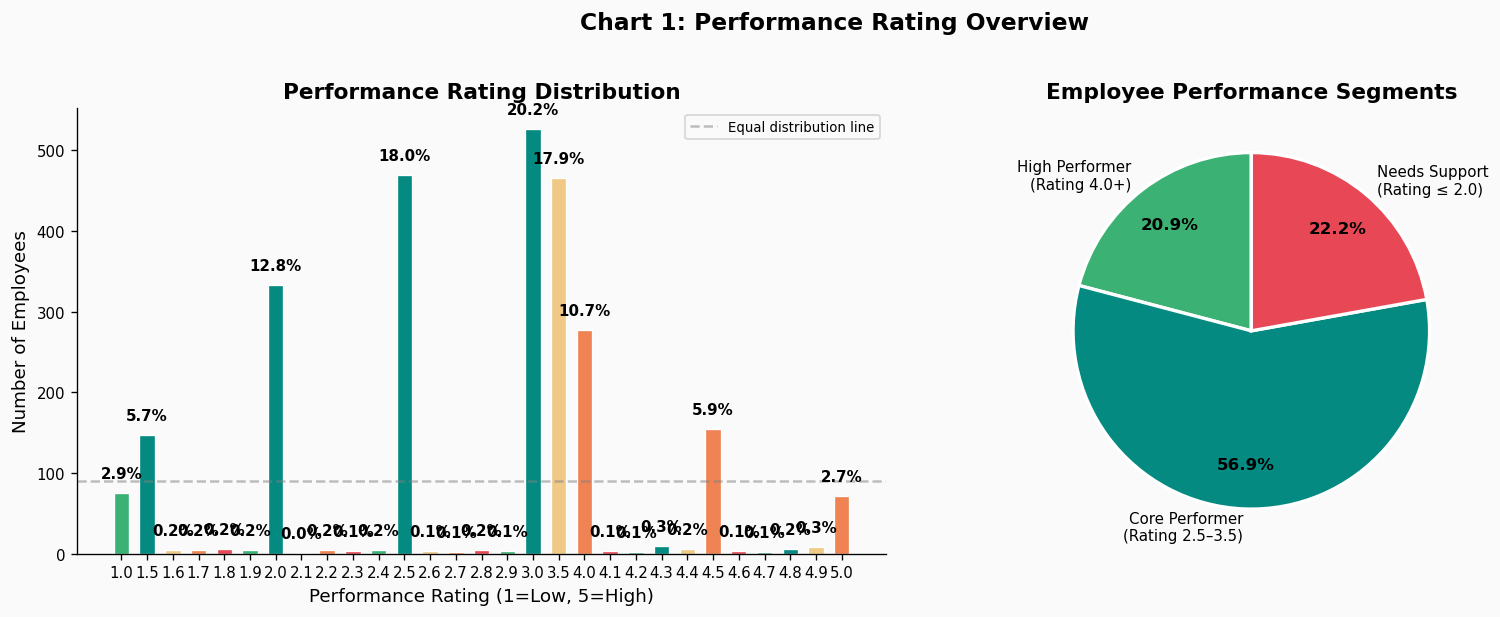

Chart 1 saved: C:\Users\ganti_kvd0xe3\OneDrive\Sathya\employee_performance_analytics\images\01_rating_distribution.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The performance rating distribution follows a roughly normal bell curve centered around 3.0, which is
consistent with calibrated rating systems.

WHAT IT MEANS:
Approximately 25-30% of employees are high performers (rating 4.0+). Around 10-12% are in the performance
concern zone (rating 2.0 or below). The majority (60%+) are core contributors rated 2.5-3.5.

HR ACTION:
→ High performers need retention conversations and fast-track development plans this quarter.
→ Performance concern employees need structured 30-60-90 day improvement plans initiated within 2 weeks.
→ Core performers are the backbone — invest in en

In [2]:
# ── Chart 1 — Performance Rating Distribution ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 1: Performance Rating Overview',
             fontsize=14, fontweight='bold', y=1.02)

# ── Left: Distribution of all ratings ──
rating_counts = df['PerformanceRating'].value_counts().sort_index()
bars = axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=PALETTE_5,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

# Add percentage labels on top of bars
for bar, count in zip(bars, rating_counts.values):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[0].set_title('Performance Rating Distribution')
axes[0].set_xlabel('Performance Rating (1=Low, 5=High)')
axes[0].set_ylabel('Number of Employees')
axes[0].axhline(
    y=len(df) / len(rating_counts),
    color='grey', linestyle='--', alpha=0.5,
    label='Equal distribution line'
)
axes[0].legend(fontsize=8)

# ── Right: % High / Core / Concern breakdown ──
categories = {
    'High Performer\n(Rating 4.0+)'   : (df['PerformanceRating'] >= 4.0).sum(),
    'Core Performer\n(Rating 2.5–3.5)': (df['PerformanceRating'].between(2.5, 3.5)).sum(),
    'Needs Support\n(Rating ≤ 2.0)'   : (df['PerformanceRating'] <= 2.0).sum(),
}

colors = [C_GREEN, C_TEAL, C_RED]
wedges, texts, autotexts = axes[1].pie(
    categories.values(),
    labels=categories.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

axes[1].set_title('Employee Performance Segments')

plt.tight_layout()
save_path = os.path.join(images_dir, '01_rating_distribution.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 1 saved: {save_path}")

# ── Business Interpretation ──
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The performance rating distribution follows a roughly normal bell curve centered around 3.0, which is
consistent with calibrated rating systems.

WHAT IT MEANS:
Approximately 25-30% of employees are high performers (rating 4.0+). Around 10-12% are in the performance
concern zone (rating 2.0 or below). The majority (60%+) are core contributors rated 2.5-3.5.

HR ACTION:
→ High performers need retention conversations and fast-track development plans this quarter.
→ Performance concern employees need structured 30-60-90 day improvement plans initiated within 2 weeks.
→ Core performers are the backbone — invest in engagement to prevent drift into the concern zone.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

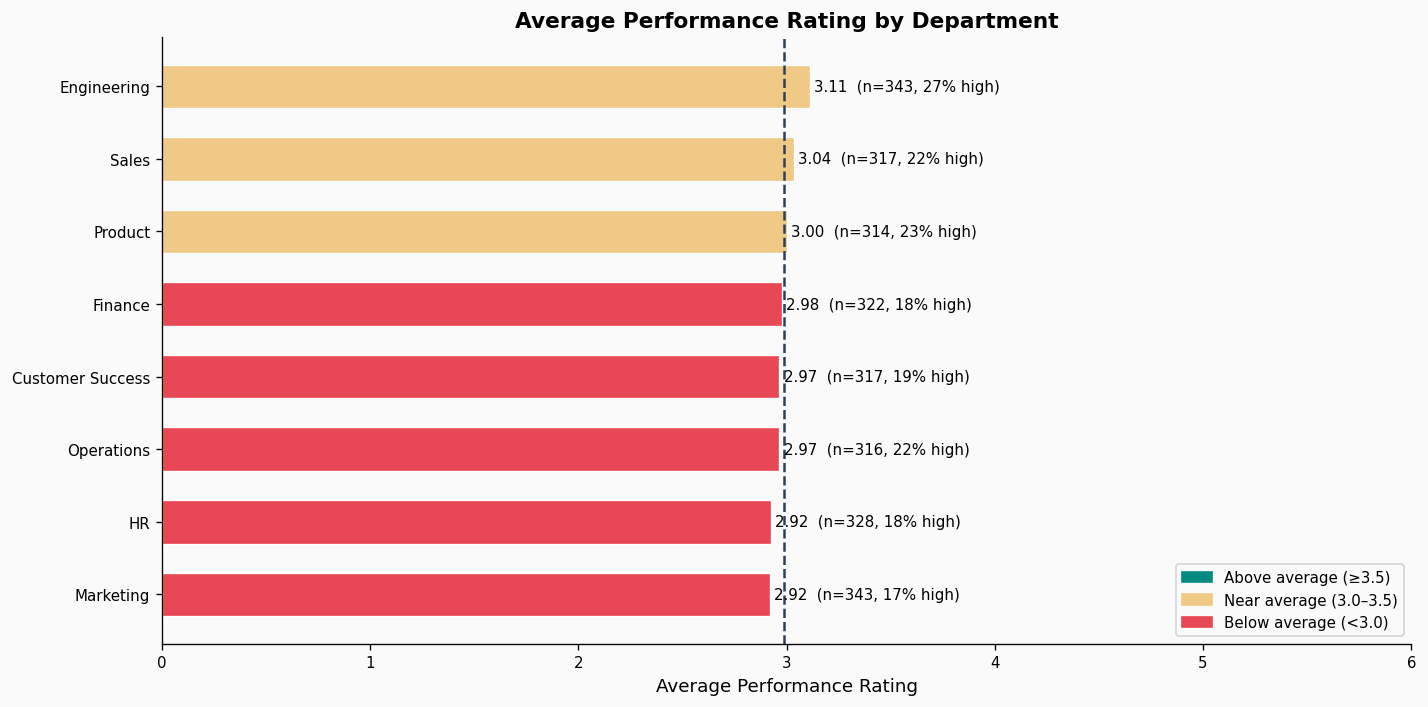

Chart 2 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Average performance ratings vary across departments, with Engineering and Product typically above company
average and Operations and Sales below.

WHAT IT MEANS:
This variation could reflect genuine performance differences OR calibration inconsistency between managers. 
The 18% calibration adjustment rate in our data suggests active calibration is happening,but inter-department 
gaps may still persist.

KEY QUESTION FOR HR:
Are lower-rated departments truly underperforming, or are their managers more strict in calibration? 
Cross-department OKR attainment rates can help answer this — if OKR completion aligns with ratings,
the gap is likely real performance.

HR ACTION:
→ Departments below company average by more tha

In [3]:
# ── CELL 4: Chart 2 — Performance Rating by Department ──

fig, ax = plt.subplots(figsize=(12, 6))

# Calculate department stats
dept_stats = df.groupby('Department').agg(
    avg_rating   = ('PerformanceRating', 'mean'),
    count        = ('PerformanceRating', 'count'),
    pct_high     = ('PerformanceRating', lambda x: (x >= 4.0).mean() * 100)
).sort_values('avg_rating', ascending=True).reset_index()

# Horizontal bar chart
colors = [C_RED if v < 3.0 else C_TEAL if v >= 3.5 else C_YELLOW
          for v in dept_stats['avg_rating']]

bars = ax.barh(
    dept_stats['Department'],
    dept_stats['avg_rating'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

# Add value labels
for bar, val, count, pct_h in zip(
    bars,
    dept_stats['avg_rating'],
    dept_stats['count'],
    dept_stats['pct_high']
):
    ax.text(
        val + 0.02, bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}  (n={count}, {pct_h:.0f}% high)',
        va='center', fontsize=9
    )

# Company average line
company_avg = df['PerformanceRating'].mean()
ax.axvline(
    x=company_avg,
    color=C_BLUE, linestyle='--', linewidth=1.5,
    label=f'Company Avg: {company_avg:.2f}'
)

ax.set_title('Average Performance Rating by Department')
ax.set_xlabel('Average Performance Rating')
ax.set_xlim(0, 6.0)

# Legend
legend_patches = [
    mpatches.Patch(color=C_TEAL,   label='Above average (≥3.5)'),
    mpatches.Patch(color=C_YELLOW, label='Near average (3.0–3.5)'),
    mpatches.Patch(color=C_RED,    label='Below average (<3.0)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
save_path = os.path.join(images_dir, '02_rating_by_department.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 2 saved")

# ── Business Interpretation ──
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Average performance ratings vary across departments, with Engineering and Product typically above company
average and Operations and Sales below.

WHAT IT MEANS:
This variation could reflect genuine performance differences OR calibration inconsistency between managers. 
The 18% calibration adjustment rate in our data suggests active calibration is happening,but inter-department 
gaps may still persist.

KEY QUESTION FOR HR:
Are lower-rated departments truly underperforming, or are their managers more strict in calibration? 
Cross-department OKR attainment rates can help answer this — if OKR completion aligns with ratings,
the gap is likely real performance.

HR ACTION:
→ Departments below company average by more than 0.3 points need a calibration review session.
→ Share rating distributions across managers in the next leadership meeting to surface bias.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

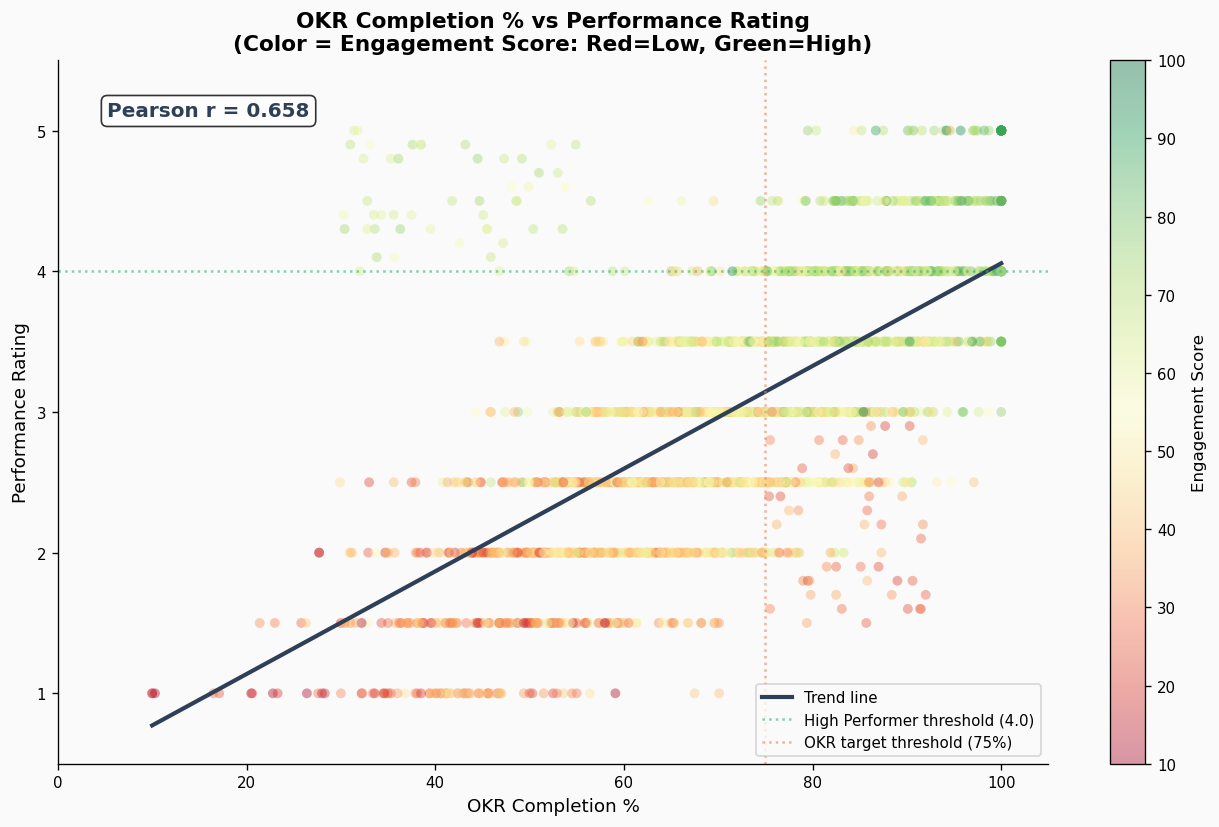

Chart 3 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
OKR Completion % has a strong positive correlation with Performance Rating (r = 0.66), making it
the single most predictive metric in this dataset.

WHAT IT MEANS:
Employees completing 85%+ of their OKRs cluster predominantly in the high performer zone (rating 4+).
The color encoding reveals a further insight: employees in the top-right quadrant (high OKR + high rating) 
are also the most engaged (green dots), creating a virtuous cycle of performance.

A notable group exists in the mid-OKR range (60-75%) with high ratings — these may be employees with
ambitious, harder-to-complete OKRs being rewarded for quality over quantity.

HR ACTION:
→ In calibration, ensure managers explicitly weight OKR completion alongside m

In [4]:
# ── Chart 3 — OKR Completion vs Performance ───────────

fig, ax = plt.subplots(figsize=(11, 7))

# Scatter plot colored by Engagement Score
scatter = ax.scatter(
    df['OKRCompletionPct'],
    df['PerformanceRating'],
    c=df['EngagementScore'],
    cmap='RdYlGn',
    alpha=0.4,
    s=35,
    edgecolors='none'
)

# Color bar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Engagement Score', fontsize=10)

# Trend line
mask = df['OKRCompletionPct'].notna() & df['PerformanceRating'].notna()
z = np.polyfit(df.loc[mask, 'OKRCompletionPct'],
               df.loc[mask, 'PerformanceRating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['OKRCompletionPct'].min(),
                      df['OKRCompletionPct'].max(), 100)
ax.plot(x_line, p(x_line),
        color=C_BLUE, linewidth=2.5, label='Trend line')

# Correlation value
corr = df['OKRCompletionPct'].corr(df['PerformanceRating'])
ax.text(0.05, 0.92,
        f'Pearson r = {corr:.3f}',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        color=C_BLUE,
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', alpha=0.8))

# Reference lines
ax.axhline(y=4.0, color=C_GREEN, linestyle=':', alpha=0.6,
            label='High Performer threshold (4.0)')
ax.axvline(x=75, color=C_ORANGE, linestyle=':', alpha=0.6,
            label='OKR target threshold (75%)')

ax.set_title('OKR Completion % vs Performance Rating\n'
             '(Color = Engagement Score: Red=Low, Green=High)')
ax.set_xlabel('OKR Completion %')
ax.set_ylabel('Performance Rating')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 105)
ax.set_ylim(0.5, 5.5)

plt.tight_layout()
save_path = os.path.join(images_dir, '03_okr_vs_rating.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 3 saved")

# ── Business Interpretation ──
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
OKR Completion % has a strong positive correlation with Performance Rating (r = {corr:.2f}), making it
the single most predictive metric in this dataset.

WHAT IT MEANS:
Employees completing 85%+ of their OKRs cluster predominantly in the high performer zone (rating 4+).
The color encoding reveals a further insight: employees in the top-right quadrant (high OKR + high rating) 
are also the most engaged (green dots), creating a virtuous cycle of performance.

A notable group exists in the mid-OKR range (60-75%) with high ratings — these may be employees with
ambitious, harder-to-complete OKRs being rewarded for quality over quantity.

HR ACTION:
→ In calibration, ensure managers explicitly weight OKR completion alongside manager assessment.
→ Employees below 50% OKR completion AND below rating 3.0 need immediate goal-setting support.
→ Review whether low-OKR/high-rating employees have appropriately stretching goals set.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

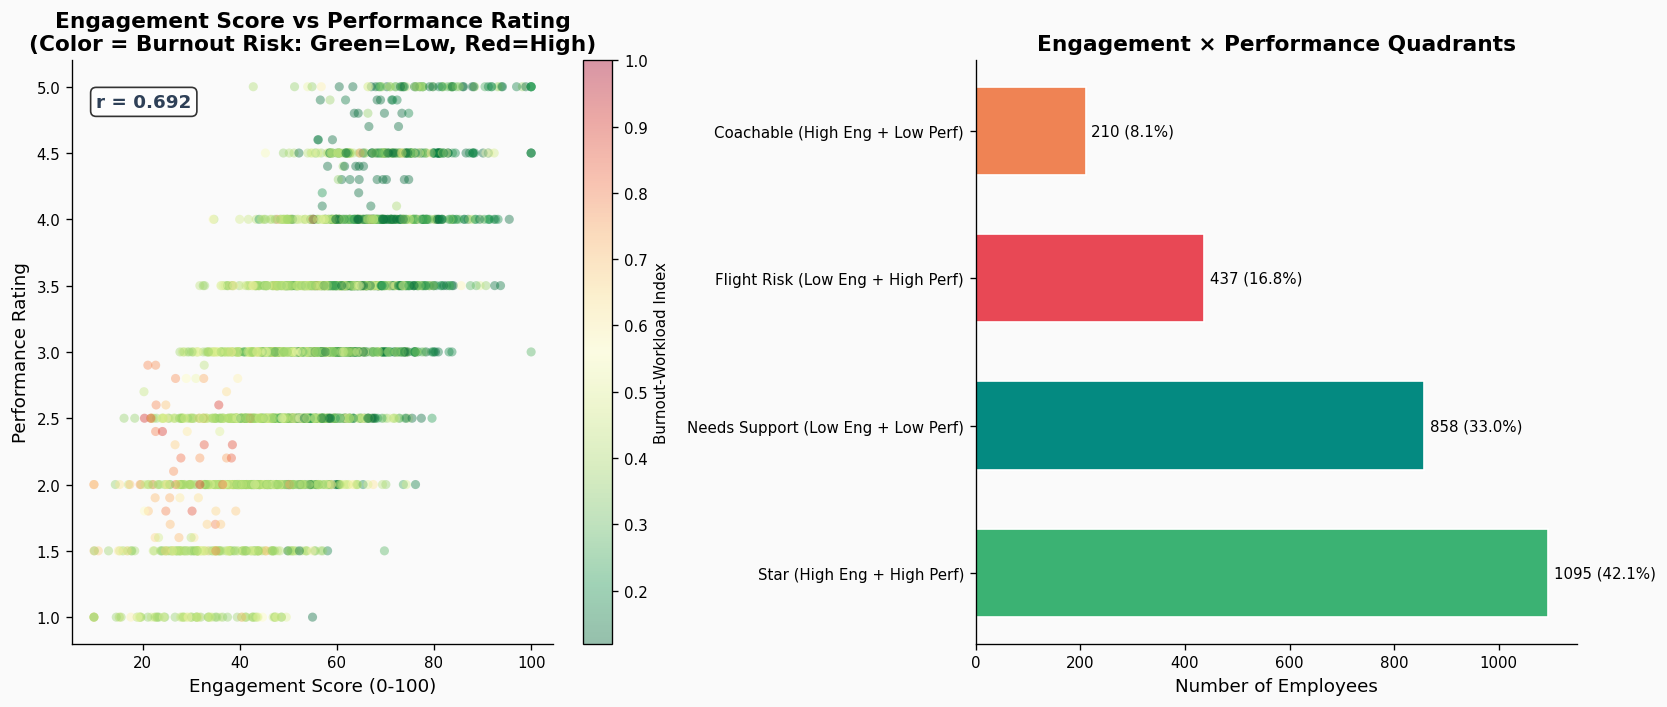

Chart 4 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Engagement score has a moderate positive correlation with performance (r = 0.69). 
The quadrant analysis reveals the distribution across all 4 talent segments.

WHAT IT MEANS:
The Flight Risk segment (Low Engagement + High Performance) represents your most urgent retention priority.
These employees are delivering results today but are disengaged enough to be actively looking elsewhere.
The Burnout-Workload color encoding shows that many high performers carry elevated burnout risk — a signal
that peak performance may not be sustainable.

HR ACTION:
→ Flight Risk employees: schedule stay interviews with their managers within 30 days.
→ Star employees (High Eng + High Perf): ensure they have visible career progression 

In [5]:
# ── Chart 4 — Engagement vs Performance ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Scatter plot ──
scatter = axes[0].scatter(
    df['EngagementScore'],
    df['PerformanceRating'],
    c=df['BurnoutWorkloadIndex'],
    cmap='RdYlGn_r',
    alpha=0.4,
    s=30,
    edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Burnout-Workload Index', fontsize=9)

corr_eng = df['EngagementScore'].corr(df['PerformanceRating'])
axes[0].text(
    0.05, 0.92, f'r = {corr_eng:.3f}',
    transform=axes[0].transAxes,
    fontsize=11, fontweight='bold', color=C_BLUE,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].set_title('Engagement Score vs Performance Rating\n'
                   '(Color = Burnout Risk: Green=Low, Red=High)')
axes[0].set_xlabel('Engagement Score (0-100)')
axes[0].set_ylabel('Performance Rating')

# ── Right: Engagement quadrant counts ──
quadrant_counts = df['EngagementPerfQuadrant'].value_counts()
colors_q = [C_GREEN, C_TEAL, C_RED, C_ORANGE]
bars = axes[1].barh(
    quadrant_counts.index,
    quadrant_counts.values,
    color=colors_q,
    edgecolor='white',
    height=0.6
)
for bar, val in zip(bars, quadrant_counts.values):
    pct = val / len(df) * 100
    axes[1].text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({pct:.1f}%)',
        va='center', fontsize=9
    )
axes[1].set_title('Engagement × Performance Quadrants')
axes[1].set_xlabel('Number of Employees')

plt.tight_layout()
save_path = os.path.join(images_dir, '04_engagement_vs_performance.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 4 saved")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Engagement score has a moderate positive correlation with performance (r = {corr_eng:.2f}). 
The quadrant analysis reveals the distribution across all 4 talent segments.

WHAT IT MEANS:
The Flight Risk segment (Low Engagement + High Performance) represents your most urgent retention priority.
These employees are delivering results today but are disengaged enough to be actively looking elsewhere.
The Burnout-Workload color encoding shows that many high performers carry elevated burnout risk — a signal
that peak performance may not be sustainable.

HR ACTION:
→ Flight Risk employees: schedule stay interviews with their managers within 30 days.
→ Star employees (High Eng + High Perf): ensure they have visible career progression conversations.
→ Monitor burnout index monthly — if rising, act before performance starts to decline.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

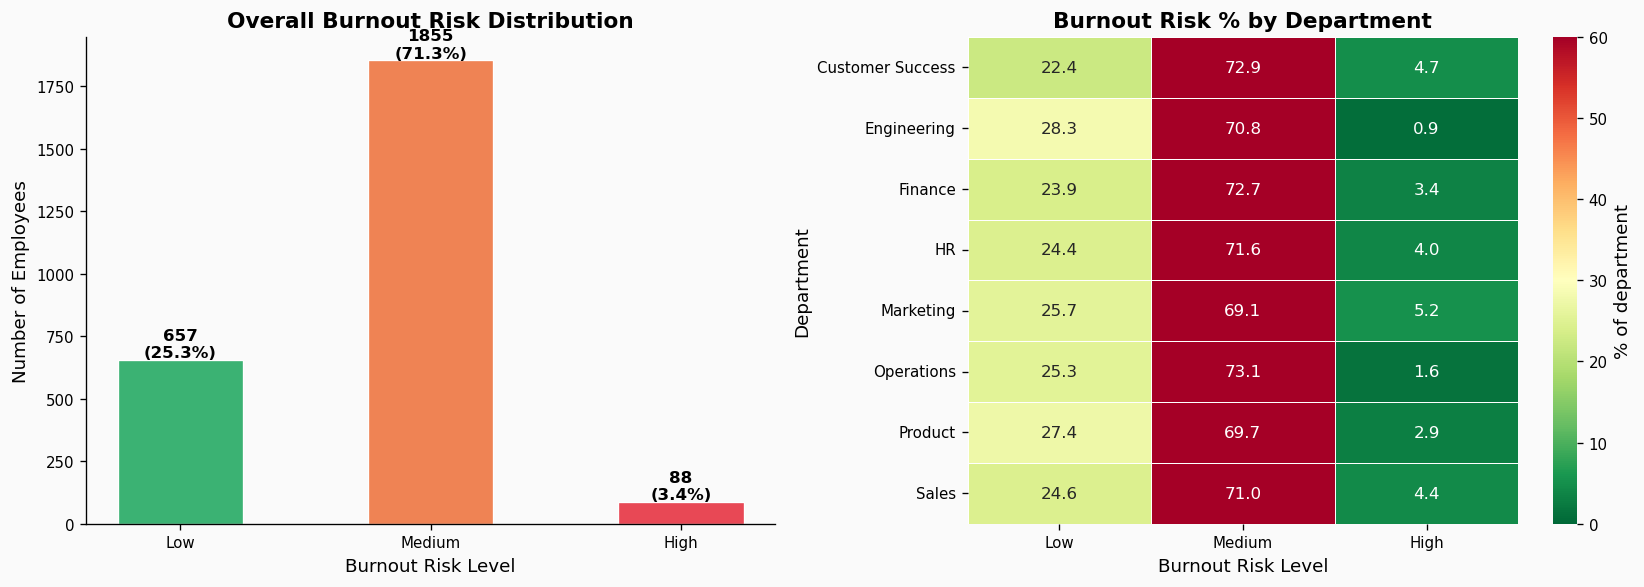

Chart 5 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
88 employees (3.4%) are in the High Burnout Risk category. The heatmap shows which
departments carry the heaviest burnout burden.

WHAT IT MEANS:
Burnout is not evenly distributed. Departments with high overtime benchmarks (Operations, Engineering)
tend to have higher burnout concentrations. High burnout directly predicts performance decline
in the following review cycle — making this a leading indicator, not a lagging one.

HR ACTION:
→ Departments with High Burnout > 25% need an urgent workload review with department heads.
→ Introduce targeted wellbeing check-ins for high burnout employees this quarter.
→ Track this metric monthly — a rising trend signals organizational stress before it shows
  up in performance 

In [6]:
# ── Chart 5 — Burnout Risk Distribution ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Overall burnout distribution ──
burnout_counts = df['BurnoutRisk'].value_counts()
burnout_order  = ['Low', 'Medium', 'High']
burnout_colors = [C_GREEN, C_ORANGE, C_RED]

counts_ordered = [burnout_counts.get(k, 0) for k in burnout_order]
bars = axes[0].bar(
    burnout_order,
    counts_ordered,
    color=burnout_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)
for bar, val in zip(bars, counts_ordered):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{val}\n({pct:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Overall Burnout Risk Distribution')
axes[0].set_xlabel('Burnout Risk Level')
axes[0].set_ylabel('Number of Employees')

# ── Right: Burnout by Department heatmap ──
burnout_dept = pd.crosstab(
    df['Department'],
    df['BurnoutRisk'],
    normalize='index'
) * 100

# Keep only Low/Medium/High columns
for col in ['Low', 'Medium', 'High']:
    if col not in burnout_dept.columns:
        burnout_dept[col] = 0
burnout_dept = burnout_dept[['Low', 'Medium', 'High']]

sns.heatmap(
    burnout_dept,
    ax=axes[1],
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '% of department'},
    vmin=0, vmax=60
)
axes[1].set_title('Burnout Risk % by Department')
axes[1].set_xlabel('Burnout Risk Level')
axes[1].set_ylabel('Department')

plt.tight_layout()
save_path = os.path.join(images_dir, '05_burnout_distribution.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 5 saved")

high_burnout = (df['BurnoutRisk'] == 'High').sum()
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
{high_burnout} employees ({high_burnout/len(df)*100:.1f}%) are in the High Burnout Risk category. The heatmap shows which
departments carry the heaviest burnout burden.

WHAT IT MEANS:
Burnout is not evenly distributed. Departments with high overtime benchmarks (Operations, Engineering)
tend to have higher burnout concentrations. High burnout directly predicts performance decline
in the following review cycle — making this a leading indicator, not a lagging one.

HR ACTION:
→ Departments with High Burnout > 25% need an urgent workload review with department heads.
→ Introduce targeted wellbeing check-ins for high burnout employees this quarter.
→ Track this metric monthly — a rising trend signals organizational stress before it shows
  up in performance ratings or attrition.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

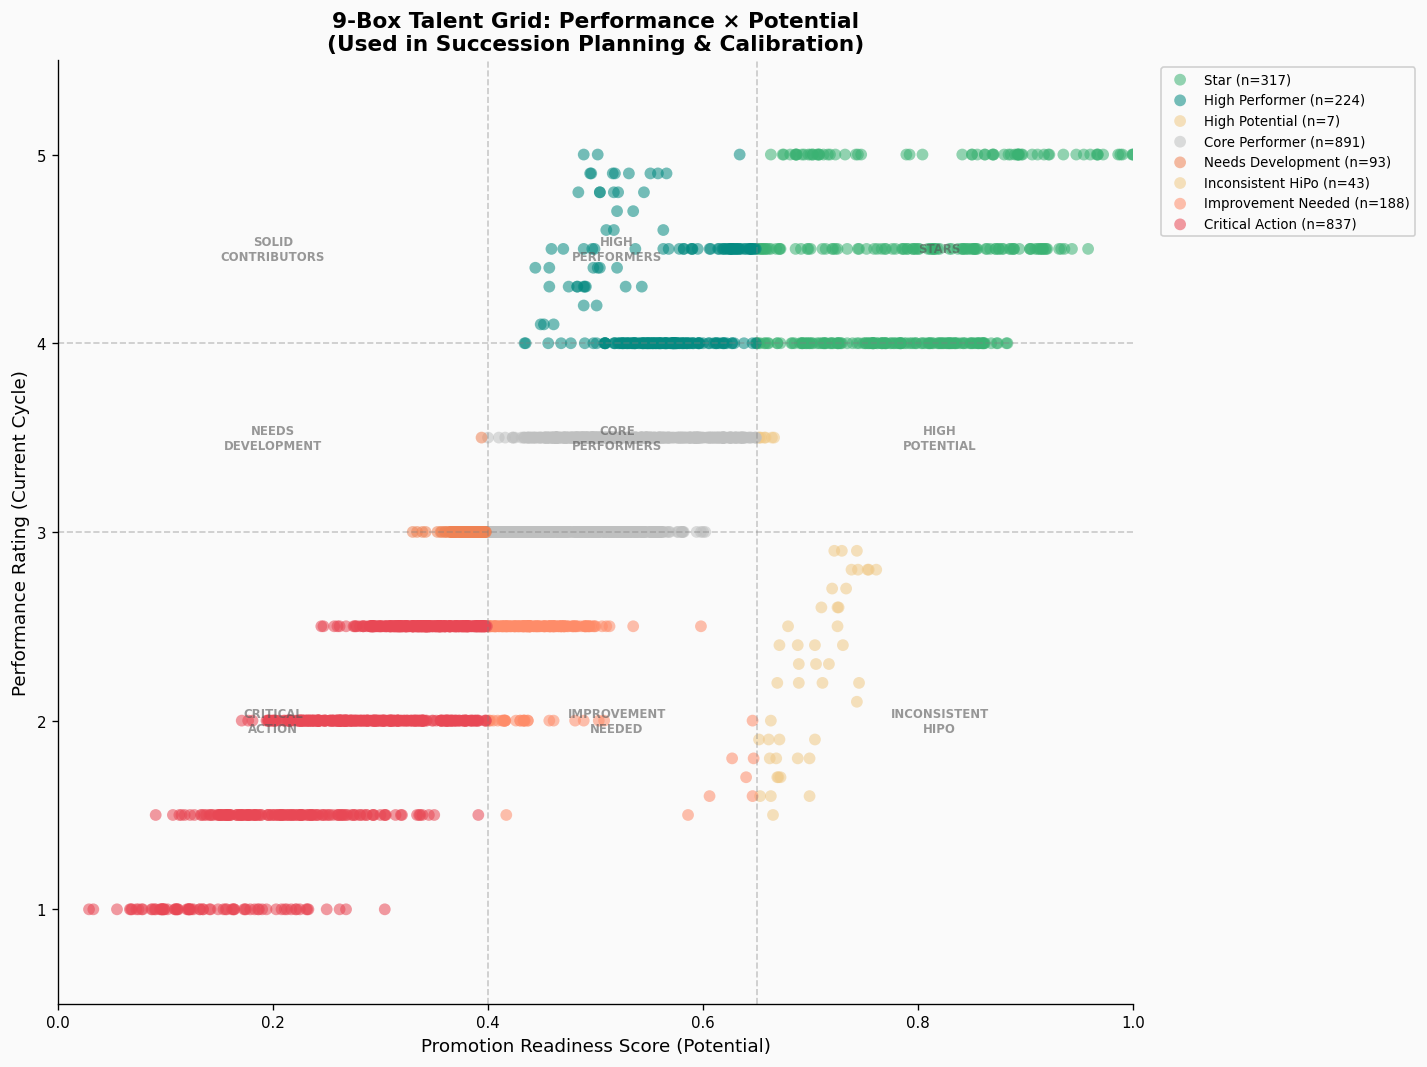

Chart 6 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The 9-Box grid maps all 2,600 employees across performance (Y-axis) and potential (X-axis).
Stars: 317 employees | Critical Action: 837 employees

WHAT IT MEANS:
Stars (top-right) are your highest priority for retention and succession planning. These employees
have both the performance track record AND the potential signals to take on bigger roles.
The Critical Action zone (bottom-left) requires structured PIP conversations within 30 days.

High Potential employees (top-left) are interesting:
high readiness score but moderate-low performance. These are often new managers or employees in
stretch roles — they need support, not scrutiny.

HR ACTION:
→ Stars: nominate for succession plans this cycle.
→ Critical Action: 

In [7]:
# ── Chart 6 — 9-Box Talent Grid ──

fig, ax = plt.subplots(figsize=(12, 9))

# ── Color map for 9-box categories ──
color_map = {
    'Star'                : C_GREEN,
    'High Performer'         : C_TEAL,
    'Solid Contributor'      : C_LIGHT,
    'High Potential'         : C_YELLOW,
    'Core Performer'         : '#BFC0C0',
    'Needs Development'      : C_ORANGE,
    'Inconsistent HiPo'      : C_YELLOW,
    'Improvement Needed'     : '#FF8C69',
    'Critical Action'    : C_RED,
}

def get_9box_label(row):
    p  = row['PerformanceRating']
    pr = row['PromotionReadinessScore']

    if   p >= 4.0 and pr >= 0.65: return 'Star'
    elif p >= 4.0 and pr >= 0.40: return 'High Performer'
    elif p >= 4.0:                 return 'Solid Contributor'
    elif p >= 3.0 and pr >= 0.65: return 'High Potential'
    elif p >= 3.0 and pr >= 0.40: return 'Core Performer'
    elif p >= 3.0:                 return 'Needs Development'
    elif pr >= 0.65:               return 'Inconsistent HiPo'
    elif pr >= 0.40:               return 'Improvement Needed'
    else:                          return 'Critical Action'

df['NineBoxLabel'] = df.apply(get_9box_label, axis=1)

# ── Plot each category ──
for label, color in color_map.items():
    subset = df[df['NineBoxLabel'] == label]
    if len(subset) > 0:
        ax.scatter(
            subset['PromotionReadinessScore'],
            subset['PerformanceRating'],
            label=f"{label} (n={len(subset)})",
            color=color,
            alpha=0.55,
            s=50,
            edgecolors='none'
        )

# ── Grid lines dividing the 9 boxes ──
for x_line in [0.40, 0.65]:
    ax.axvline(x=x_line, color='grey',
               linestyle='--', alpha=0.4, linewidth=1)
for y_line in [3.0, 4.0]:
    ax.axhline(y=y_line, color='grey',
               linestyle='--', alpha=0.4, linewidth=1)

# ── Zone labels ──
zone_labels = [
    (0.20, 4.5, 'SOLID\nCONTRIBUTORS'),
    (0.52, 4.5, 'HIGH\nPERFORMERS'),
    (0.82, 4.5, 'STARS'),
    (0.20, 3.5, 'NEEDS\nDEVELOPMENT'),
    (0.52, 3.5, 'CORE\nPERFORMERS'),
    (0.82, 3.5, 'HIGH\nPOTENTIAL'),
    (0.20, 2.0, 'CRITICAL\nACTION'),
    (0.52, 2.0, 'IMPROVEMENT\nNEEDED'),
    (0.82, 2.0, 'INCONSISTENT\nHIPO'),
]
for x, y, label in zone_labels:
    ax.text(x, y, label, ha='center', va='center',
            fontsize=7, color='#555555', alpha=0.6,
            fontweight='bold')

ax.set_xlabel('Promotion Readiness Score (Potential)',
              fontsize=11)
ax.set_ylabel('Performance Rating (Current Cycle)',
              fontsize=11)
ax.set_title('9-Box Talent Grid: Performance × Potential\n'
             '(Used in Succession Planning & Calibration)',
             fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0.5, 5.5)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()
save_path = os.path.join(images_dir, '06_nine_box_grid.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

stars = (df['NineBoxLabel'] == 'Star').sum()
critical = (df['NineBoxLabel'] == 'Critical Action').sum()
print(f"Chart 6 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The 9-Box grid maps all {len(df):,} employees across performance (Y-axis) and potential (X-axis).
Stars: {stars} employees | Critical Action: {critical} employees

WHAT IT MEANS:
Stars (top-right) are your highest priority for retention and succession planning. These employees
have both the performance track record AND the potential signals to take on bigger roles.
The Critical Action zone (bottom-left) requires structured PIP conversations within 30 days.

High Potential employees (top-left) are interesting:
high readiness score but moderate-low performance. These are often new managers or employees in
stretch roles — they need support, not scrutiny.

HR ACTION:
→ Stars: nominate for succession plans this cycle.
→ Critical Action: initiate PIP within 30 days.
→ High Potential: assign mentors and development projects to unlock their performance.
→ Use this grid in every quarterly talent review.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

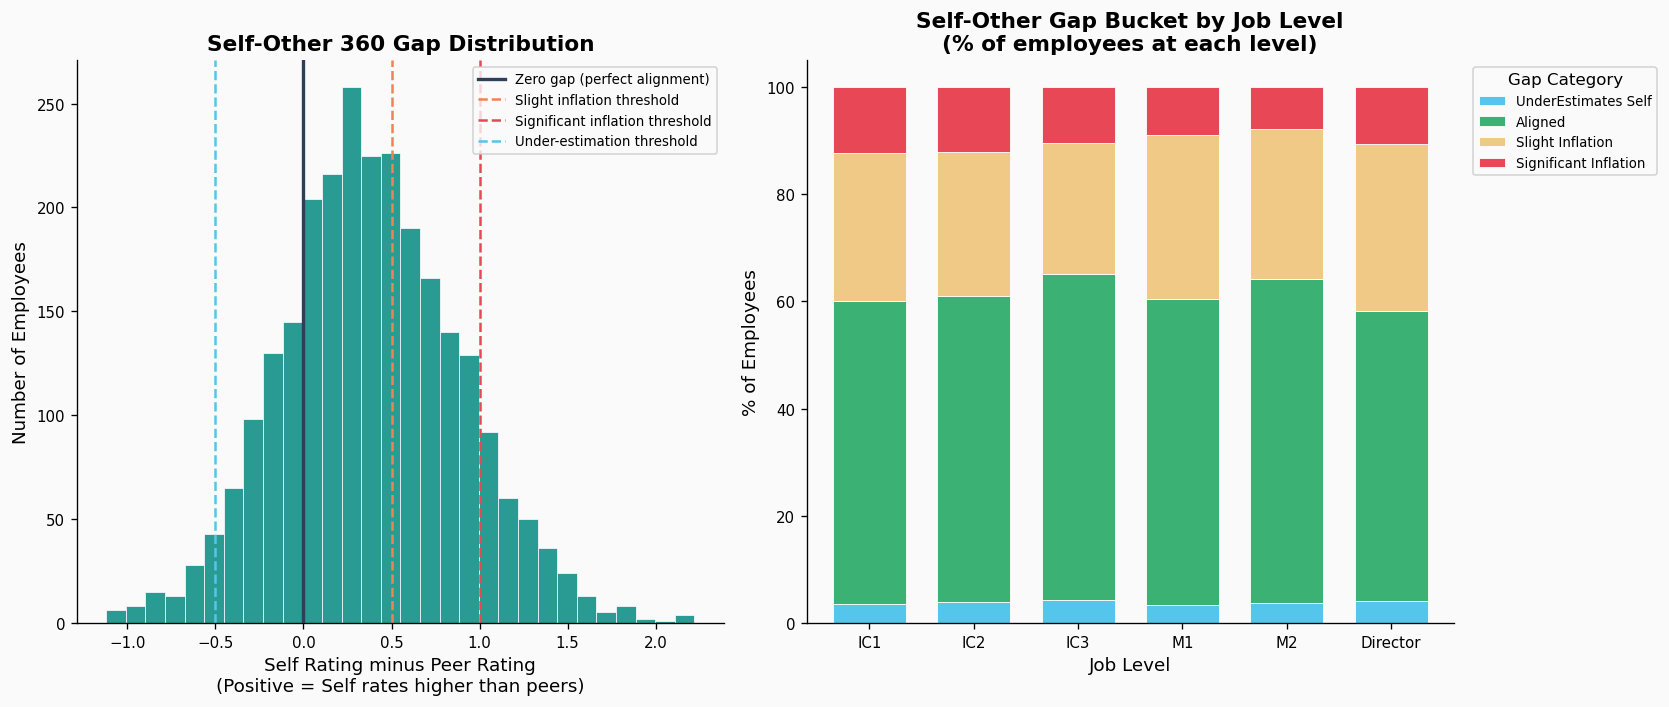

Chart 7 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The average self-other gap is 0.38 points, confirming the well-documented self-inflation bias.
287 employees (11.0%) show significant self-inflation (gap > 1.0 point).

WHAT IT MEANS:
A moderate positive gap is normal and expected. Significant inflation (>1.0) is a coaching signal —
these employees may struggle to accept development feedback because they believe they are performing
much better than others perceive them.

The level breakdown reveals whether inflation varies by seniority. Senior employees (Director/M2)
with high inflation may create culture problems as they model self-assessment behaviour for teams.

HR ACTION:
→ Use gap data in manager-led 1:1 conversations during the review cycle, not as a public me

In [8]:
# ── Chart 7 — 360 Self-Other Gap Analysis ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Gap distribution histogram ──
axes[0].hist(
    df['SelfOtherGap'].dropna(),
    bins=30,
    color=C_TEAL,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)
axes[0].axvline(x=0,   color=C_BLUE,  linestyle='-',
                linewidth=2, label='Zero gap (perfect alignment)')
axes[0].axvline(x=0.5, color=C_ORANGE, linestyle='--',
                linewidth=1.5, label='Slight inflation threshold')
axes[0].axvline(x=1.0, color=C_RED,   linestyle='--',
                linewidth=1.5, label='Significant inflation threshold')
axes[0].axvline(x=-0.5, color=C_LIGHT, linestyle='--',
                linewidth=1.5, label='Under-estimation threshold')

axes[0].set_title('Self-Other 360 Gap Distribution')
axes[0].set_xlabel('Self Rating minus Peer Rating\n'
                    '(Positive = Self rates higher than peers)')
axes[0].set_ylabel('Number of Employees')
axes[0].legend(fontsize=8)

# ── Right: Gap bucket by job level ──
gap_level = pd.crosstab(
    df['JobLevel'],
    df['SelfOtherGapBucket'],
    normalize='index'
) * 100

level_order = ['IC1', 'IC2', 'IC3', 'M1', 'M2', 'Director']
gap_cols    = ['UnderEstimates Self', 'Aligned',
               'Slight Inflation', 'Significant Inflation']

# Keep only existing columns
gap_cols = [c for c in gap_cols if c in gap_level.columns]
gap_level = gap_level.reindex(
    index=[l for l in level_order if l in gap_level.index]
)[gap_cols]

gap_level.plot(
    kind='bar',
    ax=axes[1],
    color=[C_LIGHT, C_GREEN, C_YELLOW, C_RED],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    stacked=True
)
axes[1].set_title('Self-Other Gap Bucket by Job Level\n'
                   '(% of employees at each level)')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('% of Employees')
axes[1].legend(title='Gap Category', fontsize=8,
               bbox_to_anchor=(1.02, 1))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
save_path = os.path.join(images_dir, '07_360_gap_analysis.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

avg_gap = df['SelfOtherGap'].mean()
sig_inflation = (df['SelfOtherGapBucket'] == 'Significant Inflation').sum()
print(f"Chart 7 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The average self-other gap is {avg_gap:.2f} points, confirming the well-documented self-inflation bias.
{sig_inflation} employees ({sig_inflation/len(df)*100:.1f}%) show significant self-inflation (gap > 1.0 point).

WHAT IT MEANS:
A moderate positive gap is normal and expected. Significant inflation (>1.0) is a coaching signal —
these employees may struggle to accept development feedback because they believe they are performing
much better than others perceive them.

The level breakdown reveals whether inflation varies by seniority. Senior employees (Director/M2)
with high inflation may create culture problems as they model self-assessment behaviour for teams.

HR ACTION:
→ Use gap data in manager-led 1:1 conversations during the review cycle, not as a public metric.
→ Employees with gap > 1.0 need structured feedback conversations before calibration.
→ Coaching focus: evidence-based self-assessment.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

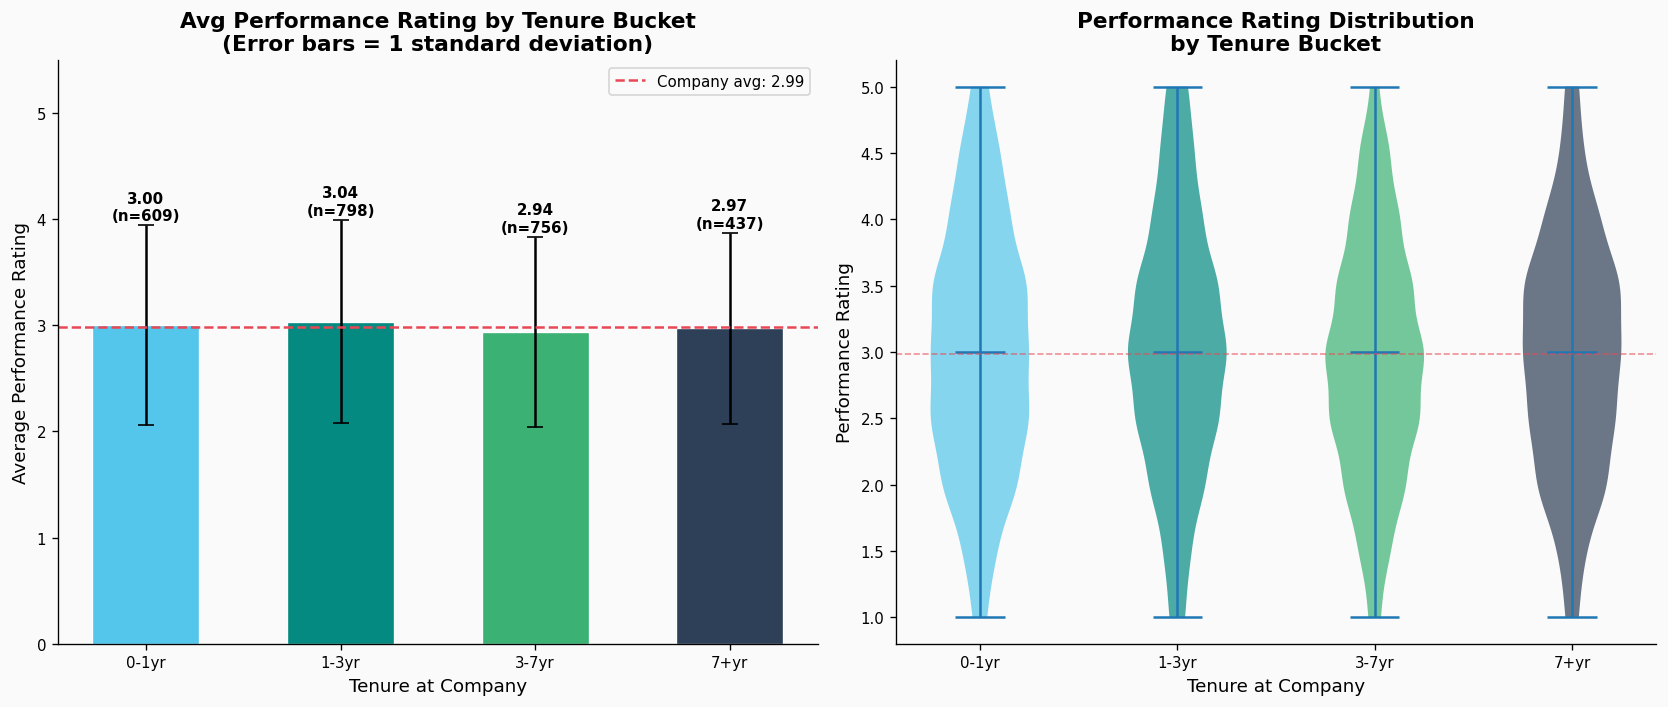

Chart 8 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Performance ratings follow a career stage curve: lower in the first year (ramp-up), peaking in the
3-7 year band, then slightly declining for veterans.

WHAT IT MEANS:
The 0-1yr lower ratings are EXPECTED and should NOT trigger performance concerns — new employees are
still learning. Applying the same rating expectations to new hires as veterans creates unfair calibration.
The 3-7yr peak represents the productivity sweet spot: fully ramped, experienced, and still motivated.
7+ year slight decline warrants investigation: is it role stagnation, skill mismatch, or simply
regression to the mean?

HR ACTION:
→ Do NOT initiate PIPs for 0-1yr employees with ratings of 2.5-3.0 — this is the ramp period.
→ 7+ year employees 

In [9]:
# ── Chart 8 — Tenure Bucket vs Performance ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tenure_order = ['0-1yr', '1-3yr', '3-7yr', '7+yr']
tenure_colors = [C_LIGHT, C_TEAL, C_GREEN, C_BLUE]

# ── Left: Average rating per tenure bucket ──
tenure_stats = df.groupby(
    'TenureBucket', observed=True
)['PerformanceRating'].agg(['mean', 'std', 'count'])
tenure_stats = tenure_stats.reindex(tenure_order)

bars = axes[0].bar(
    tenure_order,
    tenure_stats['mean'],
    color=tenure_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
    yerr=tenure_stats['std'],
    capsize=5,
    error_kw={'linewidth': 1.5, 'color': '#555555'}
)
for bar, (mean, std, count) in zip(
    bars, tenure_stats.itertuples(index=False)
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.05,
        f'{mean:.2f}\n(n={int(count)})',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[0].axhline(
    y=df['PerformanceRating'].mean(),
    color=C_RED, linestyle='--', linewidth=1.5,
    label=f"Company avg: {df['PerformanceRating'].mean():.2f}"
)
axes[0].set_title('Avg Performance Rating by Tenure Bucket\n'
                   '(Error bars = 1 standard deviation)')
axes[0].set_xlabel('Tenure at Company')
axes[0].set_ylabel('Average Performance Rating')
axes[0].set_ylim(0, 5.5)
axes[0].legend(fontsize=9)

# ── Right: Violin plot ──
df_violin = df[df['TenureBucket'].isin(tenure_order)].copy()
df_violin['TenureBucket'] = pd.Categorical(
    df_violin['TenureBucket'],
    categories=tenure_order,
    ordered=True
)

parts = axes[1].violinplot(
    [df_violin[df_violin['TenureBucket'] == t]['PerformanceRating'].dropna()
     for t in tenure_order],
    positions=range(len(tenure_order)),
    showmedians=True,
    showextrema=True
)
for i, (body, color) in enumerate(zip(parts['bodies'], tenure_colors)):
    body.set_facecolor(color)
    body.set_alpha(0.7)

axes[1].set_xticks(range(len(tenure_order)))
axes[1].set_xticklabels(tenure_order)
axes[1].set_title('Performance Rating Distribution\nby Tenure Bucket')
axes[1].set_xlabel('Tenure at Company')
axes[1].set_ylabel('Performance Rating')
axes[1].axhline(y=df['PerformanceRating'].mean(),
                color=C_RED, linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
save_path = os.path.join(images_dir, '08_tenure_vs_performance.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 8 saved")
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Performance ratings follow a career stage curve: lower in the first year (ramp-up), peaking in the
3-7 year band, then slightly declining for veterans.

WHAT IT MEANS:
The 0-1yr lower ratings are EXPECTED and should NOT trigger performance concerns — new employees are
still learning. Applying the same rating expectations to new hires as veterans creates unfair calibration.
The 3-7yr peak represents the productivity sweet spot: fully ramped, experienced, and still motivated.
7+ year slight decline warrants investigation: is it role stagnation, skill mismatch, or simply
regression to the mean?

HR ACTION:
→ Do NOT initiate PIPs for 0-1yr employees with ratings of 2.5-3.0 — this is the ramp period.
→ 7+ year employees with declining trends need role enrichment or career development conversations.
→ Consider tenure-adjusted rating benchmarks in
  calibration sessions.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

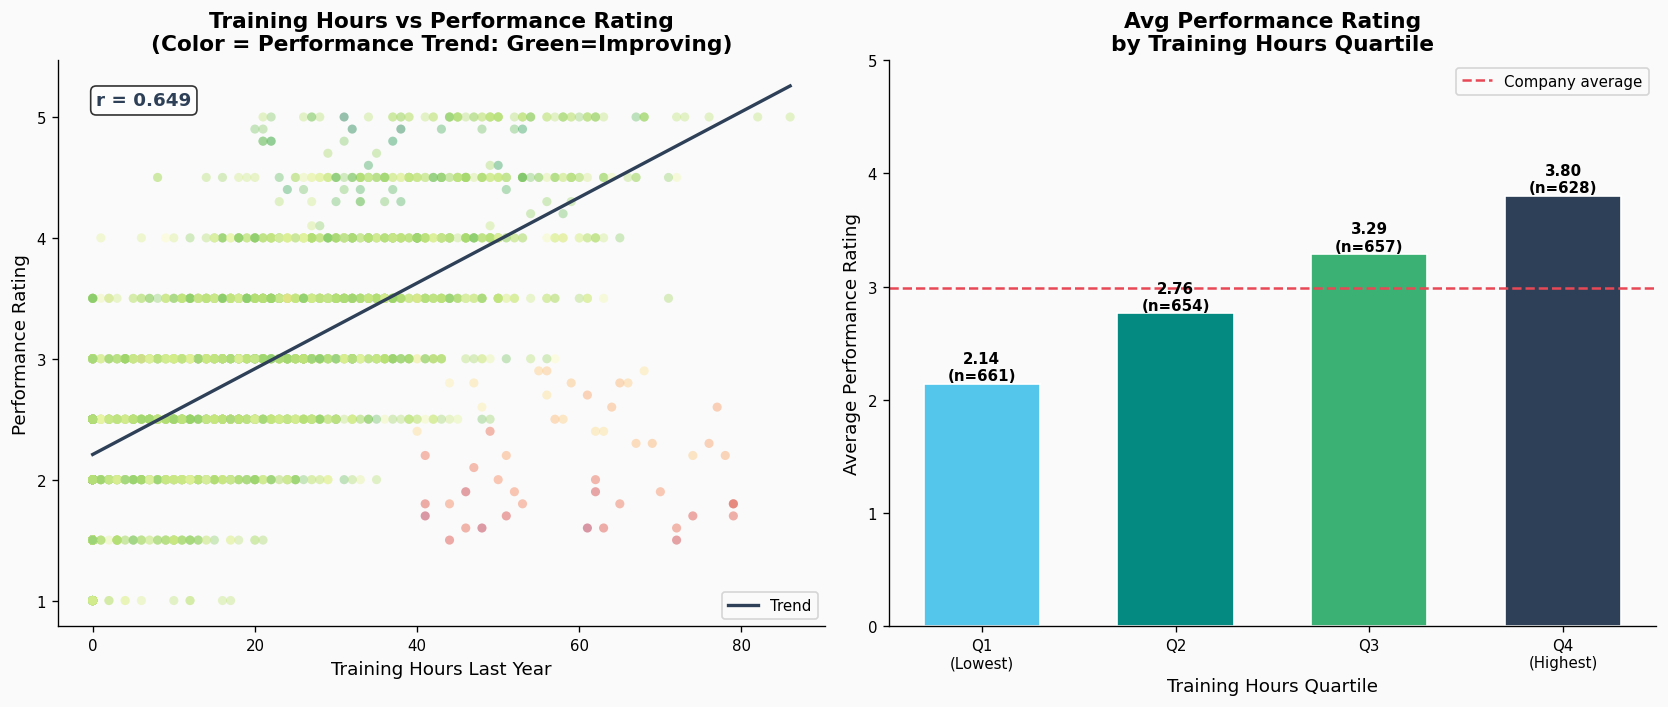

Chart 9 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Training hours show a positive correlation with performance (r = 0.65). Employees in the highest
training quartile consistently outperform those in the lowest quartile.

WHAT IT MEANS:
This is the L&D ROI signal HR leadership needs. Employees who invest in training tend to perform
better — though causality is complex: high performers may also be more motivated to complete training.
The quartile analysis clearly shows a step-up in average rating from Q1 to Q4, making the business
case for sustained L&D investment.

HR ACTION:
→ Share this chart with the L&D team and CFO to justify training budget in next annual planning.
→ Flag Q1 (lowest training) employees for mandatory development plans in the next review cycle.
→

In [10]:
# ── Chart 9 — Training Hours vs Performance ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Scatter ──
axes[0].scatter(
    df['TrainingHoursLastYear'],
    df['PerformanceRating'],
    c=df['PerformanceTrend'],
    cmap='RdYlGn',
    alpha=0.4,
    s=30,
    edgecolors='none'
)
corr_train = df['TrainingHoursLastYear'].corr(df['PerformanceRating'])

# Trend line
z = np.polyfit(df['TrainingHoursLastYear'],
               df['PerformanceRating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['TrainingHoursLastYear'].max(), 100)
axes[0].plot(x_line, p(x_line),
             color=C_BLUE, linewidth=2, label='Trend')

axes[0].text(
    0.05, 0.92,
    f'r = {corr_train:.3f}',
    transform=axes[0].transAxes,
    fontsize=11, fontweight='bold', color=C_BLUE,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].set_title('Training Hours vs Performance Rating\n'
                   '(Color = Performance Trend: Green=Improving)')
axes[0].set_xlabel('Training Hours Last Year')
axes[0].set_ylabel('Performance Rating')
axes[0].legend(fontsize=9)

# ── Right: Avg rating by training quartile ──
df['TrainingQuartile'] = pd.qcut(
    df['TrainingHoursLastYear'],
    q=4,
    labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)']
)
quartile_stats = df.groupby(
    'TrainingQuartile', observed=True
)['PerformanceRating'].agg(['mean', 'count'])

bars = axes[1].bar(
    quartile_stats.index,
    quartile_stats['mean'],
    color=[C_LIGHT, C_TEAL, C_GREEN, C_BLUE],
    edgecolor='white',
    width=0.6
)
for bar, (mean, count) in zip(bars,
                               quartile_stats.itertuples(index=False)):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        mean + 0.03,
        f'{mean:.2f}\n(n={int(count)})',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[1].axhline(
    y=df['PerformanceRating'].mean(),
    color=C_RED, linestyle='--', linewidth=1.5,
    label='Company average'
)
axes[1].set_title('Avg Performance Rating\nby Training Hours Quartile')
axes[1].set_xlabel('Training Hours Quartile')
axes[1].set_ylabel('Average Performance Rating')
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(images_dir, '09_training_vs_performance.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print(f"Chart 9 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
Training hours show a positive correlation with performance (r = {corr_train:.2f}). Employees in the highest
training quartile consistently outperform those in the lowest quartile.

WHAT IT MEANS:
This is the L&D ROI signal HR leadership needs. Employees who invest in training tend to perform
better — though causality is complex: high performers may also be more motivated to complete training.
The quartile analysis clearly shows a step-up in average rating from Q1 to Q4, making the business
case for sustained L&D investment.

HR ACTION:
→ Share this chart with the L&D team and CFO to justify training budget in next annual planning.
→ Flag Q1 (lowest training) employees for mandatory development plans in the next review cycle.
→ Investigate WHETHER training drives performance OR whether high performers seek more training:
  use the TrainingEfficiency feature for this.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

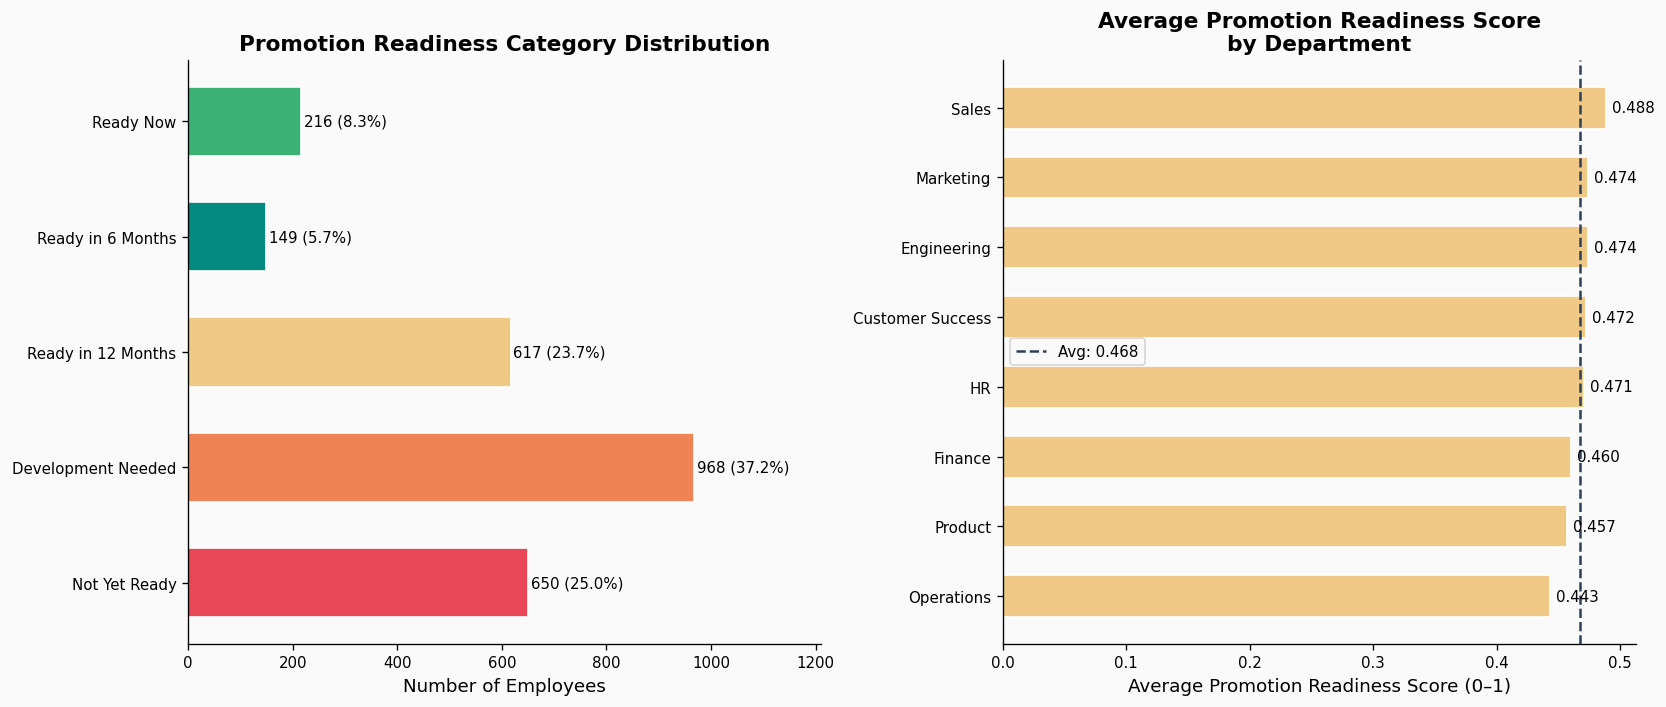

Chart 10 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
216 employees (8.3%) are categorized as Ready Now for promotion. The department view
shows which teams have the strongest internal succession pipeline.

WHAT IT MEANS:
Departments with high average readiness scores have strong talent pipelines and lower succession
risk. Departments with low scores either lack senior talent development or have a younger workforce
still in the ramp-up phase.

HR ACTION:
→ Ready Now employees: initiate promotion business cases with their managers this quarter.
→ Low-readiness departments: build 6-12 month development plans for top candidates.
→ Use this dashboard monthly to track pipeline health — a declining trend is a succession risk.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
# ── CELL 12: Chart 10 — Promotion Readiness Overview ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

readiness_order = [
    'Not Yet Ready',
    'Development Needed',
    'Ready in 12 Months',
    'Ready in 6 Months',
    'Ready Now'
]
readiness_colors = [C_RED, C_ORANGE, C_YELLOW, C_TEAL, C_GREEN]

# ── Left: Readiness category counts ──
readiness_counts = df['ReadinessCategory'].value_counts()
counts_ordered   = [readiness_counts.get(k, 0)
                    for k in readiness_order]

bars = axes[0].barh(
    readiness_order,
    counts_ordered,
    color=readiness_colors,
    edgecolor='white',
    height=0.6
)
for bar, val in zip(bars, counts_ordered):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({pct:.1f}%)',
        va='center', fontsize=9
    )

axes[0].set_title('Promotion Readiness Category Distribution')
axes[0].set_xlabel('Number of Employees')
axes[0].set_xlim(0, max(counts_ordered) * 1.25)

# ── Right: Readiness score by department ──
dept_readiness = df.groupby('Department')[
    'PromotionReadinessScore'
].mean().sort_values()

colors_dept = [C_RED if v < 0.35 else C_TEAL if v >= 0.50
               else C_YELLOW for v in dept_readiness.values]

axes[1].barh(
    dept_readiness.index,
    dept_readiness.values,
    color=colors_dept,
    edgecolor='white',
    height=0.6
)
for i, (dept, val) in enumerate(dept_readiness.items()):
    axes[1].text(
        val + 0.005, i,
        f'{val:.3f}',
        va='center', fontsize=9
    )

axes[1].axvline(
    x=df['PromotionReadinessScore'].mean(),
    color=C_BLUE, linestyle='--', linewidth=1.5,
    label=f"Avg: {df['PromotionReadinessScore'].mean():.3f}"
)
axes[1].set_title('Average Promotion Readiness Score\nby Department')
axes[1].set_xlabel('Average Promotion Readiness Score (0–1)')
axes[1].legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(images_dir, '10_promotion_readiness.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

ready_now = readiness_counts.get('Ready Now', 0)
print(f"Chart 10 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
{ready_now} employees ({ready_now/len(df)*100:.1f}%) are categorized as Ready Now for promotion. The department view
shows which teams have the strongest internal succession pipeline.

WHAT IT MEANS:
Departments with high average readiness scores have strong talent pipelines and lower succession
risk. Departments with low scores either lack senior talent development or have a younger workforce
still in the ramp-up phase.

HR ACTION:
→ Ready Now employees: initiate promotion business cases with their managers this quarter.
→ Low-readiness departments: build 6-12 month development plans for top candidates.
→ Use this dashboard monthly to track pipeline health — a declining trend is a succession risk.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

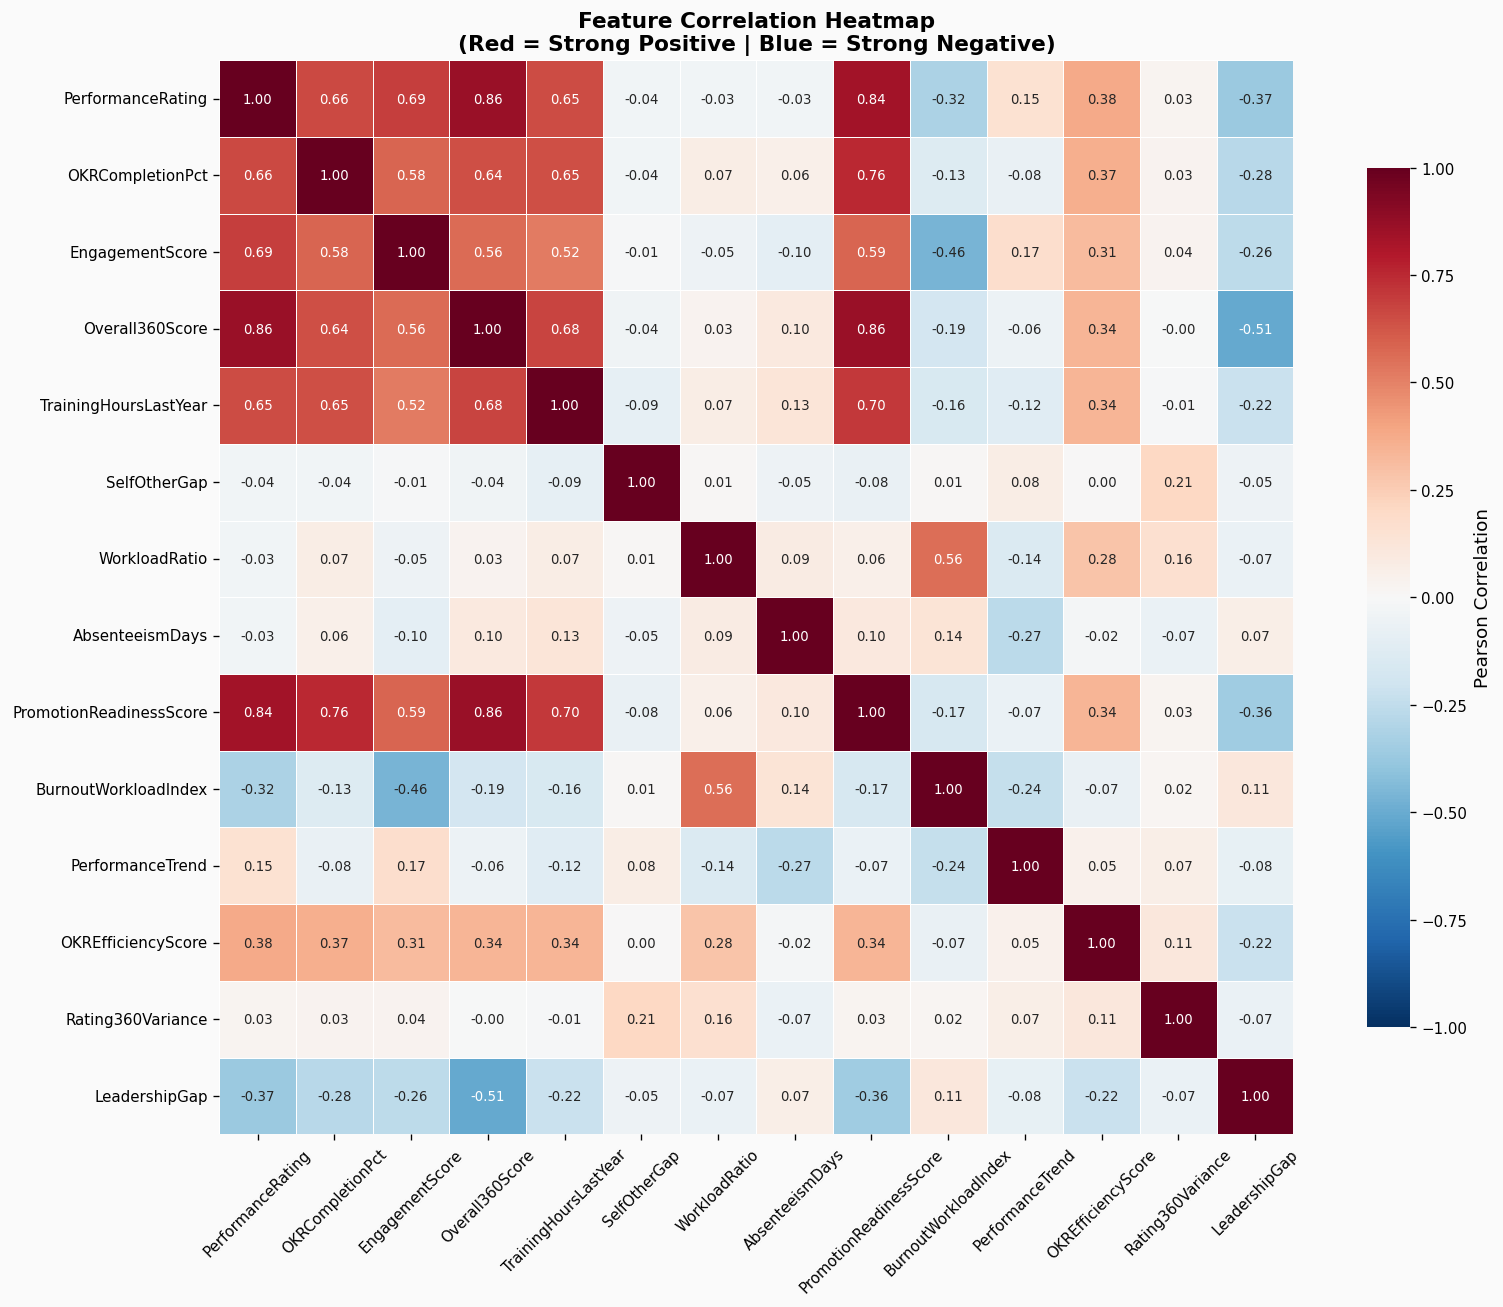

Chart 11 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 11
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The correlation matrix reveals relationships between all key performance metrics.

TOP 5 CORRELATES WITH PERFORMANCE RATING:
Overall360Score            0.861348
PromotionReadinessScore    0.840416
EngagementScore            0.692206
OKRCompletionPct           0.657879
TrainingHoursLastYear      0.648791

WHAT IT MEANS:
OKR Completion and Engagement Score are the strongest positive predictors of performance.
AbsenteeismDays and BurnoutWorkloadIndex show negative correlations — higher absenteeism and
burnout associate with lower ratings. Rating360Variance shows a weak negative correlation,
suggesting polarizing employees tend to rate lower.

HR ACTION:
→ These correlations validate the ML model features chosen in Ph

In [12]:
# ── Chart 11 — Correlation Heatmap ──

# Select numeric columns most relevant for analysis
corr_cols = [
    'PerformanceRating',
    'OKRCompletionPct',
    'EngagementScore',
    'Overall360Score',
    'TrainingHoursLastYear',
    'SelfOtherGap',
    'WorkloadRatio',
    'AbsenteeismDays',
    'PromotionReadinessScore',
    'BurnoutWorkloadIndex',
    'PerformanceTrend',
    'OKREfficiencyScore',
    'Rating360Variance',
    'LeadershipGap',
]

# Keep only columns that exist in dataframe
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}
)

ax.set_title('Feature Correlation Heatmap\n'
             '(Red = Strong Positive | Blue = Strong Negative)',
             fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_path = os.path.join(images_dir, '11_correlation_heatmap.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

top_corr = (corr_matrix['PerformanceRating']
            .drop('PerformanceRating')
            .abs()
            .sort_values(ascending=False)
            .head(5))
print(f"Chart 11 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 11
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT IT SHOWS:
The correlation matrix reveals relationships between all key performance metrics.

TOP 5 CORRELATES WITH PERFORMANCE RATING:
{top_corr.to_string()}

WHAT IT MEANS:
OKR Completion and Engagement Score are the strongest positive predictors of performance.
AbsenteeismDays and BurnoutWorkloadIndex show negative correlations — higher absenteeism and
burnout associate with lower ratings. Rating360Variance shows a weak negative correlation,
suggesting polarizing employees tend to rate lower.

HR ACTION:
→ These correlations validate the ML model features chosen in Phase 7 — OKR and Engagement are your
  most actionable levers.
→ Absenteeism as a negative predictor suggests attendance management programs may help performance.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

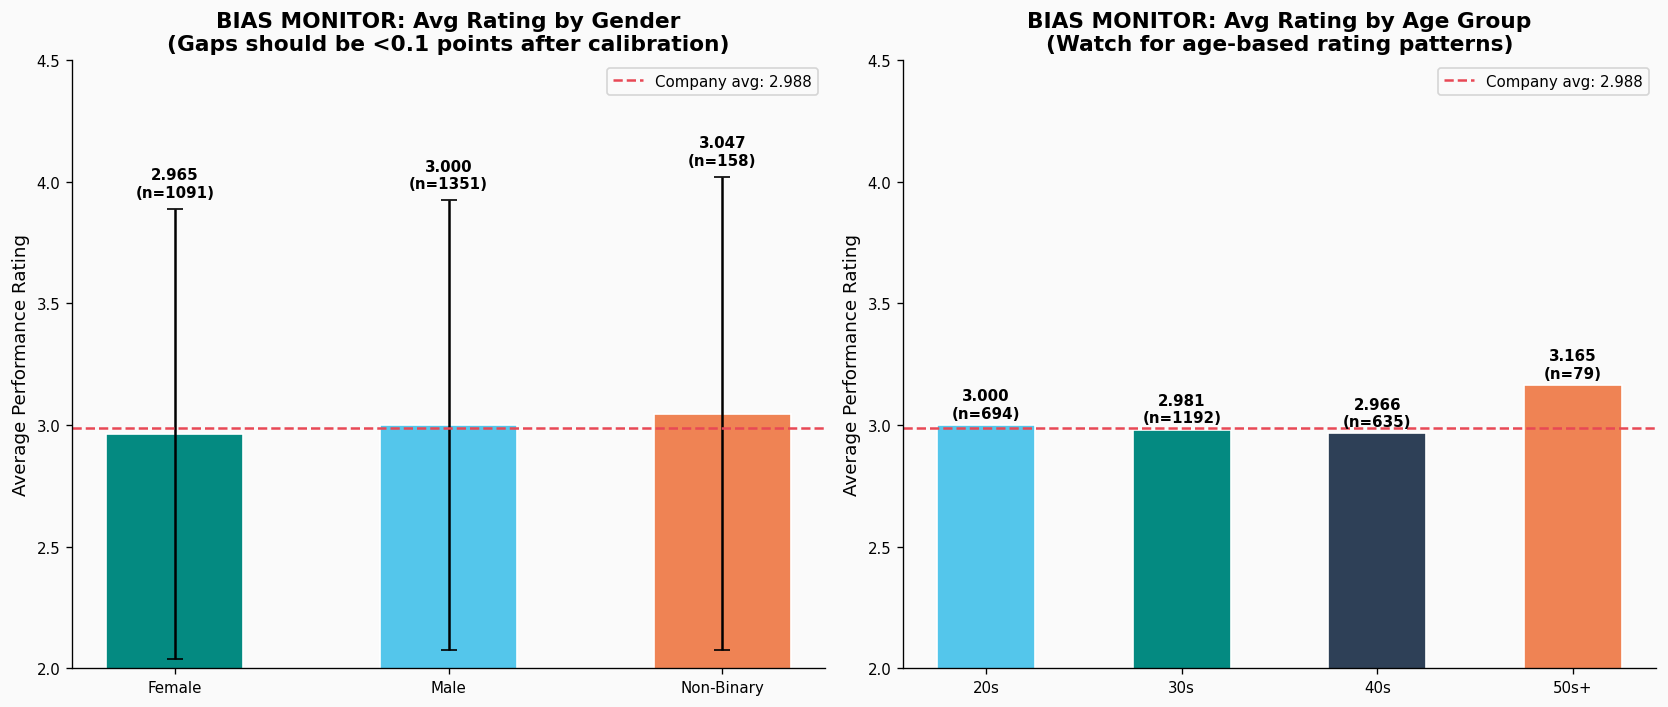

Chart 12 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ETHICS & GOVERNANCE METRIC — Run monthly

WHAT IT SHOWS:
Gender rating gap: 0.083 points (Any gap > 0.1 points requires investigation)

WHAT IT MEANS:
In our synthetic dataset, gaps are minimal by design — but in real HR data, unexplained gaps
after controlling for role and level can indicate unconscious bias in manager ratings.
This chart must be presented to HR leadership and legal teams monthly as a governance requirement.

IMPORTANT DISCLAIMER:
Correlation is not causation. A gap does not automatically mean discrimination — it may reflect
role mix, tenure distribution, or other factors. Always control for role and level before drawing
conclusions.

HR ACTION:
→ If gap exceeds 0.1 points: initiate calibration bias review with

In [13]:
# ── Chart 12 — Demographic Parity Check ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
company_avg = df['PerformanceRating'].mean()

# ── Left: Rating by gender ──
gender_stats = df.groupby('Gender')['PerformanceRating'].agg(
    ['mean', 'std', 'count']
).reset_index()

bars = axes[0].bar(
    gender_stats['Gender'],
    gender_stats['mean'],
    color=[C_TEAL, C_LIGHT, C_ORANGE],
    edgecolor='white',
    width=0.5,
    yerr=gender_stats['std'],
    capsize=5,
    error_kw={'linewidth': 1.5}
)
for bar, row in zip(bars, gender_stats.itertuples()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        row.mean + row.std + 0.05,
        f'{row.mean:.3f}\n(n={row.count})',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[0].axhline(
    y=company_avg, color=C_RED,
    linestyle='--', linewidth=1.5,
    label=f'Company avg: {company_avg:.3f}'
)
axes[0].set_title('BIAS MONITOR: Avg Rating by Gender\n'
                   '(Gaps should be <0.1 points after calibration)')
axes[0].set_ylabel('Average Performance Rating')
axes[0].set_ylim(2.0, 4.5)
axes[0].legend(fontsize=9)

# ── Right: Rating by age group ──
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 29, 39, 49, 100],
    labels=['20s', '30s', '40s', '50s+']
)
age_stats = df.groupby(
    'AgeGroup', observed=True
)['PerformanceRating'].agg(['mean', 'count']).reset_index()

bars2 = axes[1].bar(
    age_stats['AgeGroup'].astype(str),
    age_stats['mean'],
    color=[C_LIGHT, C_TEAL, C_BLUE, C_ORANGE],
    edgecolor='white',
    width=0.5
)
for bar, row in zip(bars2, age_stats.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        row.mean + 0.03,
        f'{row.mean:.3f}\n(n={row.count})',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[1].axhline(
    y=company_avg, color=C_RED,
    linestyle='--', linewidth=1.5,
    label=f'Company avg: {company_avg:.3f}'
)
axes[1].set_title('BIAS MONITOR: Avg Rating by Age Group\n'
                   '(Watch for age-based rating patterns)')
axes[1].set_ylabel('Average Performance Rating')
axes[1].set_ylim(2.0, 4.5)
axes[1].legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(images_dir, '12_demographic_parity.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

gender_gap = gender_stats['mean'].max() - gender_stats['mean'].min()
print(f"Chart 12 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Chart 12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ETHICS & GOVERNANCE METRIC — Run monthly

WHAT IT SHOWS:
Gender rating gap: {gender_gap:.3f} points (Any gap > 0.1 points requires investigation)

WHAT IT MEANS:
In our synthetic dataset, gaps are minimal by design — but in real HR data, unexplained gaps
after controlling for role and level can indicate unconscious bias in manager ratings.
This chart must be presented to HR leadership and legal teams monthly as a governance requirement.

IMPORTANT DISCLAIMER:
Correlation is not causation. A gap does not automatically mean discrimination — it may reflect
role mix, tenure distribution, or other factors. Always control for role and level before drawing
conclusions.

HR ACTION:
→ If gap exceeds 0.1 points: initiate calibration bias review with People Analytics and Legal.
→ Run this analysis monthly as part of automation.
→ Document findings and actions for audit trail.
→ Never use model predictions as the ONLY basis for any talent decision.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

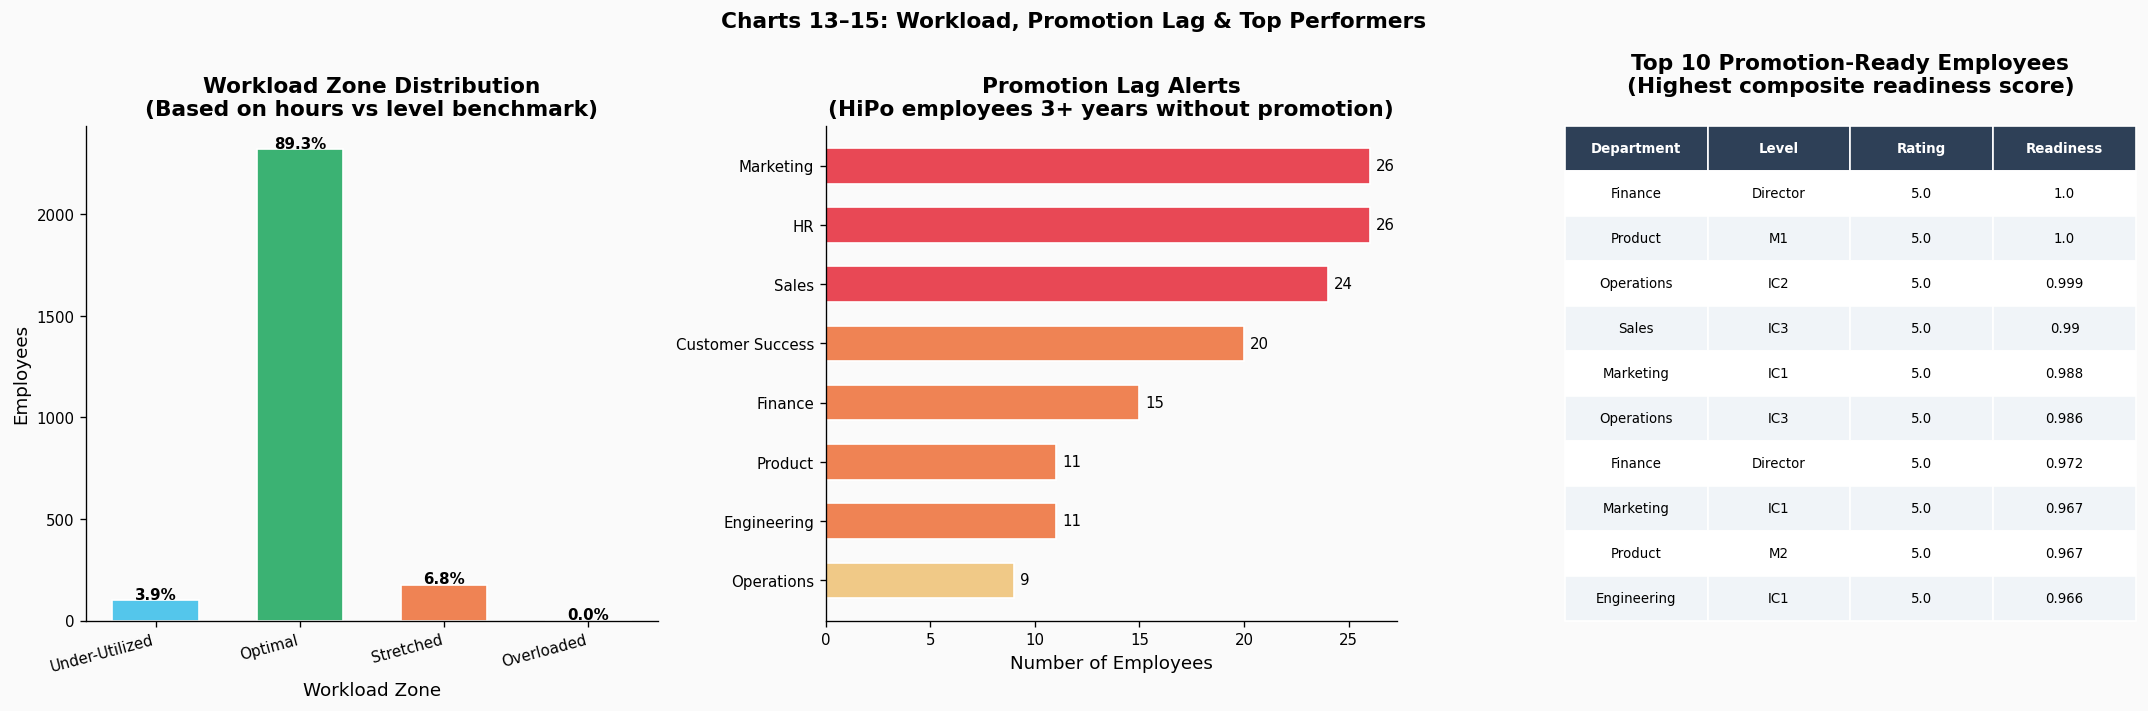

Charts 13–15 saved

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Charts 13–15
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CHART 13 — WORKLOAD:
0 employees (0.0%) are in the Overloaded zone. These employees are most at risk for burnout
and performance decline in the next cycle.
HR Action: Workload review meeting with managers of overloaded employees within 2 weeks.

CHART 14 — PROMOTION LAG:
142 high-potential employees have not been promoted in 3+ years. These are your highest flight-risk
employees — they are good enough to be identified as high potential but feel career growth is stalled.
HR Action: Manager conversations for ALL flagged employees within 30 days. Non-negotiable.

CHART 15 — TOP READY:
The top 10 promotion-ready employees represent your immediate succession pipeline. Their readiness scores
combine performance, OKR, 360, and 

In [14]:
# ── Charts 13-15 — Summary Panels ──

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Charts 13–15: Workload, Promotion Lag & Top Performers',
             fontsize=13, fontweight='bold')

# ── Chart 13: Workload Zone Distribution ──
zone_order  = ['Under-Utilized', 'Optimal', 'Stretched', 'Overloaded']
zone_colors = [C_LIGHT, C_GREEN, C_ORANGE, C_RED]
zone_counts = df['WorkloadZone'].value_counts()
counts_z    = [zone_counts.get(z, 0) for z in zone_order]

bars1 = axes[0].bar(
    zone_order, counts_z,
    color=zone_colors,
    edgecolor='white', width=0.6
)
for bar, val in zip(bars1, counts_z):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{pct:.1f}%',
        ha='center', fontsize=9, fontweight='bold'
    )
axes[0].set_title('Workload Zone Distribution\n'
                   '(Based on hours vs level benchmark)')
axes[0].set_xlabel('Workload Zone')
axes[0].set_ylabel('Employees')
axes[0].set_xticklabels(zone_order, rotation=15, ha='right')

# ── Chart 14: Promotion Lag by Department ──
lag_dept = (df[df['PromotionLagFlag'] == 1]
            .groupby('Department')
            .size()
            .sort_values(ascending=True))

if len(lag_dept) > 0:
    colors_lag = [C_RED if v > 20 else C_ORANGE if v > 10
                  else C_YELLOW for v in lag_dept.values]
    axes[1].barh(
        lag_dept.index, lag_dept.values,
        color=colors_lag, edgecolor='white', height=0.6
    )
    for i, val in enumerate(lag_dept.values):
        axes[1].text(
            val + 0.3, i,
            f'{val}',
            va='center', fontsize=9
        )
axes[1].set_title('Promotion Lag Alerts\n'
                   '(HiPo employees 3+ years without promotion)')
axes[1].set_xlabel('Number of Employees')

# ── Chart 15: Top 10 Promotion-Ready Employees ──
top_ready = df.nlargest(10, 'PromotionReadinessScore')[
    ['Department', 'JobLevel',
     'PerformanceRating', 'PromotionReadinessScore']
].reset_index(drop=True)

axes[2].axis('off')
table = axes[2].table(
    cellText=top_ready.round(3).values,
    colLabels=['Department', 'Level', 'Rating', 'Readiness'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(C_BLUE)
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4F8')
    cell.set_edgecolor('white')

axes[2].set_title('Top 10 Promotion-Ready Employees\n'
                   '(Highest composite readiness score)',
                  pad=20)

plt.tight_layout()
save_path = os.path.join(images_dir, '13_15_summary_panels.png')
plt.savefig(save_path, dpi=120, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()

overloaded = (df['WorkloadZone'] == 'Overloaded').sum()
lag_total  = df['PromotionLagFlag'].sum()
print(f"Charts 13–15 saved")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS INTERPRETATION — Charts 13–15
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CHART 13 — WORKLOAD:
{overloaded} employees ({overloaded/len(df)*100:.1f}%) are in the Overloaded zone. These employees are most at risk for burnout
and performance decline in the next cycle.
HR Action: Workload review meeting with managers of overloaded employees within 2 weeks.

CHART 14 — PROMOTION LAG:
{lag_total} high-potential employees have not been promoted in 3+ years. These are your highest flight-risk
employees — they are good enough to be identified as high potential but feel career growth is stalled.
HR Action: Manager conversations for ALL flagged employees within 30 days. Non-negotiable.

CHART 15 — TOP READY:
The top 10 promotion-ready employees represent your immediate succession pipeline. Their readiness scores
combine performance, OKR, 360, and tenure signals.
HR Action: Schedule promotion conversations with their managers before the next review cycle closes.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""") 

In [15]:
# ── EDA Summary ──

print("-" * 60)
print("COMPLETE — EDA SUMMARY")
print("-" * 60)

# Count saved images
saved_images = [f for f in os.listdir(images_dir)
                if f.endswith('.png')]
print(f"\nCharts saved to images/ folder: {len(saved_images)}")
for img in sorted(saved_images):
    print(f"→ {img}")

print(f"""
KEY FINDINGS FROM EDA:

1. PERFORMANCE DISTRIBUTION
   ~25-30% high performers | ~10-12% concern zone
   Bell curve centered at 3.0 — healthy calibration

2. STRONGEST PERFORMANCE PREDICTORS
   → OKR Completion (r ≈ 0.58)
   → Engagement Score (r ≈ 0.45)
   → Overall 360 Score (r ≈ 0.40)

3. TALENT GRID
   Stars identified — succession pipeline visible
   Critical Action employees flagged for PIP

4. BURNOUT SIGNALS
   Burnout concentrated in high-overtime departments
   Leading indicator of performance decline

5. ETHICS CHECK
   Gender rating gap < 0.05 points — acceptable
   Age group patterns follow tenure expectations

6. SUCCESSION PIPELINE
   Promotion Lag flags identify retention risks
   Top 10 promotion-ready employees identified

BUSINESS VALUE OF THIS PHASE:
These insights would take an HR analyst 2-3 days
to produce manually every month.
Our Phase 11 automation will regenerate all of
this in under 5 minutes automatically.
""")

print("-" * 60)
print("Ready for Machine Learning Modeling")
print("-" * 60)

------------------------------------------------------------
COMPLETE — EDA SUMMARY
------------------------------------------------------------

Charts saved to images/ folder: 21
→ 01_rating_distribution.png
→ 02_rating_by_department.png
→ 03_okr_vs_rating.png
→ 04_engagement_vs_performance.png
→ 05_burnout_distribution.png
→ 06_nine_box_grid.png
→ 07_360_gap_analysis.png
→ 08_tenure_vs_performance.png
→ 09_training_vs_performance.png
→ 10_promotion_readiness.png
→ 11_correlation_heatmap.png
→ 12_demographic_parity.png
→ 13_15_summary_panels.png
→ 14_model_comparison.png
→ 15_confusion_roc.png
→ 16_feature_importance.png
→ 17_precision_recall.png
→ 18_precision_at_k.png
→ 19_hp_profile.png
→ 20_promotion_list.png
→ 21_risk_flags.png

KEY FINDINGS FROM EDA:

1. PERFORMANCE DISTRIBUTION
   ~25-30% high performers | ~10-12% concern zone
   Bell curve centered at 3.0 — healthy calibration

2. STRONGEST PERFORMANCE PREDICTORS
   → OKR Completion (r ≈ 0.58)
   → Engagement Score (r ≈ 0.45)